Let's look at all approaches discussed so far and plot their performance against
each other.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_timings(file_paths):
    averaged_data = {}

    for label, file_path in file_paths.items():
        df = pd.read_csv(file_path)
        avg_df = df.groupby('x')['time'].mean().reset_index()
        averaged_data[label] = avg_df

    plt.figure(figsize=(10, 6))
    for label, avg_df in averaged_data.items():
        plt.plot(avg_df['x'] + 1, avg_df['time'], marker='o', label=label)

    plt.xlabel('Number of dimensions')
    plt.ylabel('Average Time (s)')
    plt.legend()
    plt.grid(True)
    plt.show()

We use the datafiles of the previous performance tests for this, so make sure to
run each notebook to generate them first (this takes a while).

So as a reminder, we have these approaches so far:

- A row-based recursive query that is able to construct a CAD for arbitrary
  dimensions.
- A column-based recursive query that uses a schema with a column for each
  coefficient, and thus assumes a fixed dimension known beforehand.
- A column-based series of queries that use additional tables to store
  intermediary results, needing some Python plumbing to move data between
  tables.

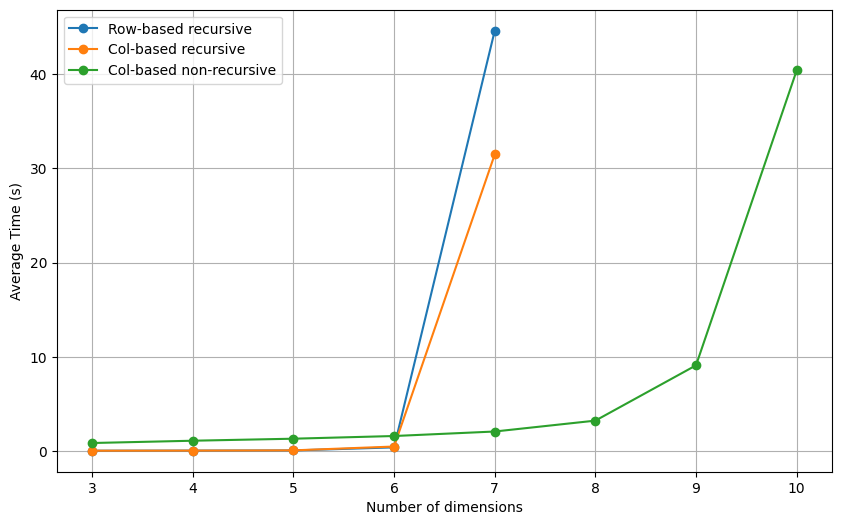

In [6]:
file_paths = {
    "Row-based recursive": "timings/basic_recursive.csv",
    "Col-based recursive": "timings/column_based.csv",
    "Col-based non-recursive": "timings/column_based_intermediate.csv",
}

plot_timings(file_paths)

These tests were run on a server with 4 CPU cores, 24GB RAM, and Ubuntu 26.04
LTS